In [ ]:
import pandas
import numpy
import matplotlib.pyplot as plt 

import tools

VOLTAGE_RESOLUTION_ERROR = 0.001/numpy.sqrt(12)
TIME_RESOLUTION_ERROR = 0.001 / numpy.sqrt(6)

def get_average_frequency(df: pandas.DataFrame):
    times = df.iloc[:, 0]
    column_name = str(times.name)
    if column_name.endswith("(ms)"):
        # to seconds
        times = times * 0.001
    elif not column_name.endswith("(s)"):
        raise Exception(f"weird dimensions for {column_name}")
    

    period = times.diff().dropna()
    period_mean = period.mean()
    period_statistical_error = period.sem()

    period_total_error = numpy.sqrt(period_statistical_error**2+TIME_RESOLUTION_ERROR**2)

    # total_error = numpy.sqrt(statistical_error**2+)

    frequency = (2*numpy.pi) / period_mean
    frequency_error = (period_total_error/(period_mean**2))
    return frequency, frequency_error


volt_to_freq = []
voltages = []
frequencies = []

for i in range(1,9):
    print(f"frequency {i}")
    peak_df = pandas.read_csv(f"frequency_{i}_peaks_2.csv")
    
    temp_volt = tools.Average.from_series(series=peak_df.iloc[:,1], errors=[VOLTAGE_RESOLUTION_ERROR])
    voltages.append(temp_volt)

    freq, freq_error = get_average_frequency(peak_df)
    temp_freq = tools.Average(mean=freq, total_error=freq_error)
    frequencies.append(temp_freq)
    
    volt_to_freq.append({
            "Voltage": temp_volt.mean,
            "Voltage_Error": temp_volt.total_error,
            "Frequency": temp_freq.mean,
            "Frequency_Error": temp_freq.total_error
        })
    

volt_to_freq = pandas.DataFrame(volt_to_freq)

print(volt_to_freq.to_csv())

frequency 1
frequency 2
frequency 3
frequency 4
frequency 5
frequency 6
frequency 7
frequency 8
,Voltage,Voltage_Error,Frequency,Frequency_Error
0,0.09315866666666667,0.0005274978372031186,89.39491290702664,0.13849232410188797
1,0.040432666666666665,0.0006790516262487781,36.02743868795634,0.10768108709605179
2,0.01803690909090907,0.0005228919371738574,14.183262544423448,0.03321903502796274
3,0.02076907692307686,0.0007067580231968128,16.49851721797703,0.05270763868612537
4,0.04449942857142858,0.0010143527811495615,39.4342174090769,0.12587028547686696
5,0.07575472727272724,0.0007707639943499106,70.28171484540924,0.20406371122296876
6,0.011175333333333317,0.0008530989261379793,6.99686559819553,0.027566653685532575
7,0.041995846153846134,0.0005231334811052148,16.110731556870736,0.15484764825295141



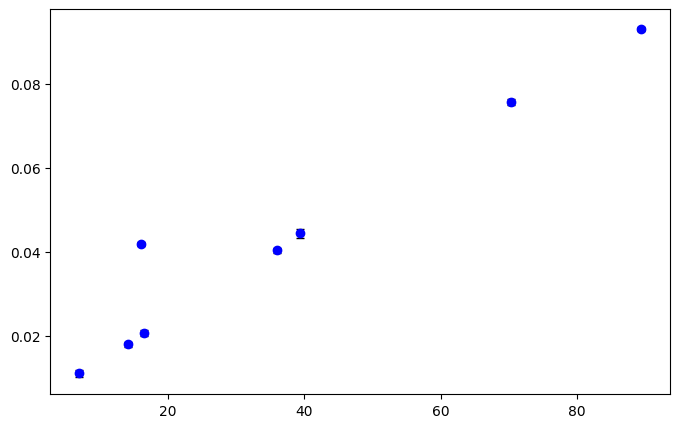

In [4]:
plt.figure(figsize=(8, 5))

tools.add_error_bar(plot=plt, x=frequencies, y=voltages, bar_config={
    "fmt": "o",
    "color": "blue",
    "ecolor": "black",
    "capsize": 3,
    "label": "Experimental Data"
})

plt.show()
